# 🚢 Titanic Survival Prediction - Data Cleaning & EDA

## 🎯 Objective
The goal of this notebook is to understand the Titanic dataset, perform exploratory data analysis (EDA), and clean the data for machine learning.

We will:
- Explore dataset structure
- Handle missing values
- Visualize key patterns
- Prepare clean data for modeling

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [10]:
data = pd.read_csv('../data/raw.csv')

## 🔍 Data Overview
Understanding the structure, data types, and summary statistics.


In [11]:

data.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [13]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## ❗ Missing Values
Identify columns with missing data.

In [14]:
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## DATA VISUALIZATION


<Axes: >

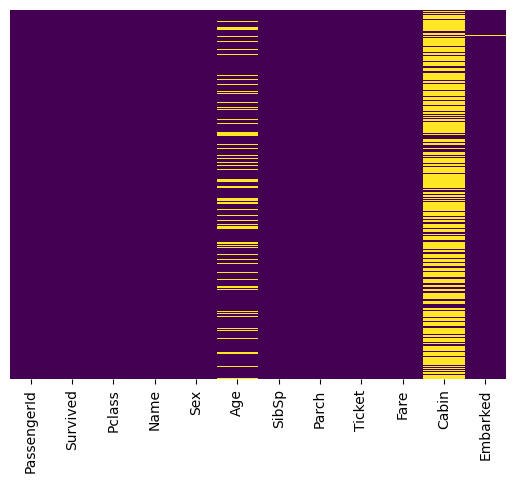

In [15]:

sns.heatmap(data.isnull(), yticklabels=False, cbar=False, cmap='viridis')

In [16]:
# Insight: Age and Cabin have missing values. We will need to handle these before building our model.

<Axes: xlabel='Survived', ylabel='count'>

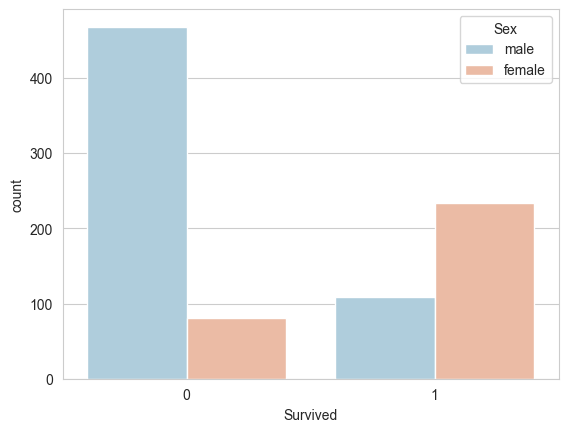

In [17]:
sns.set_style('whitegrid')
sns.countplot(x='Survived', data=data, palette='RdBu_r',hue='Sex')

In [18]:
#Insight: Females had a much higher survival rate than males.

<Axes: xlabel='Age', ylabel='Count'>

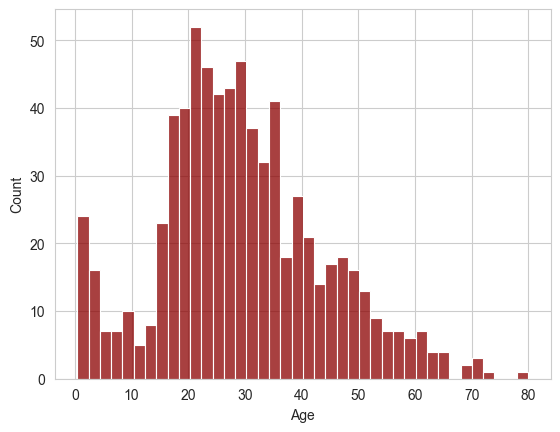

In [19]:
sns.histplot(data['Age'].dropna(), kde=False, color='darkred', bins=40)

In [20]:
#Insight: Age distribution is skewed towards younger passengers, with a significant number of children and young adults.

<Axes: xlabel='Fare', ylabel='Count'>

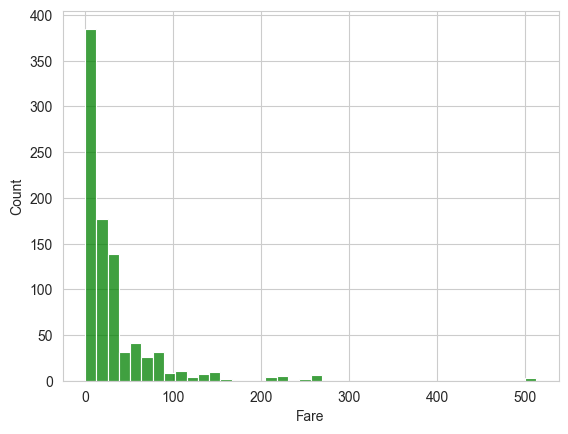

In [21]:
sns.histplot(data['Fare'], kde=False, color='green', bins=40)

In [22]:
#Insight: Fare distribution is right-skewed, with most passengers paying lower fares and a few paying very high fares.

<Axes: xlabel='SibSp', ylabel='count'>

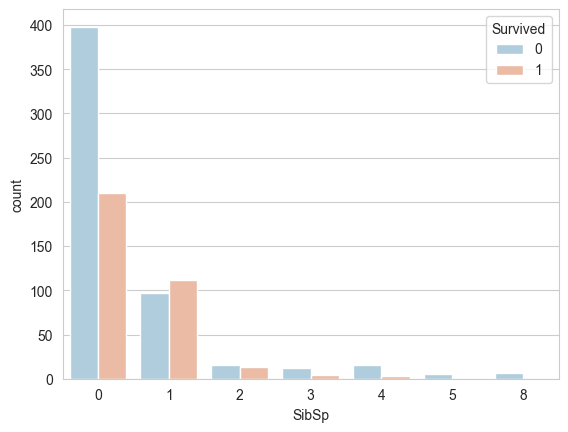

In [23]:
sns.countplot(x='SibSp', data=data, palette='RdBu_r',hue='Survived')

In [24]:
#Insight: SibSp (number of siblings/spouses aboard) has a significant impact on survival, with those having 1 or 2 siblings/spouses having higher survival rates.

C:\Users\G POORNIMADEVI\AppData\Local\Temp\ipykernel_14420\3613152198.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Pclass', y='Age', data=data, palette='winter')


<Axes: xlabel='Pclass', ylabel='Age'>

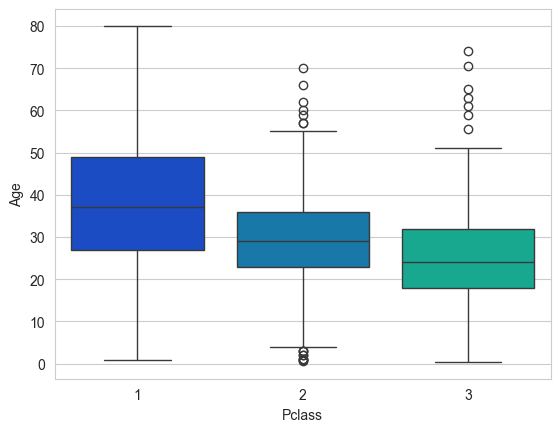

In [25]:
sns.boxplot(x='Pclass', y='Age', data=data, palette='winter')

In [26]:
#Insight:Pclass (passenger class) has a significant impact on age distribution, with higher classes having older passengers on average.

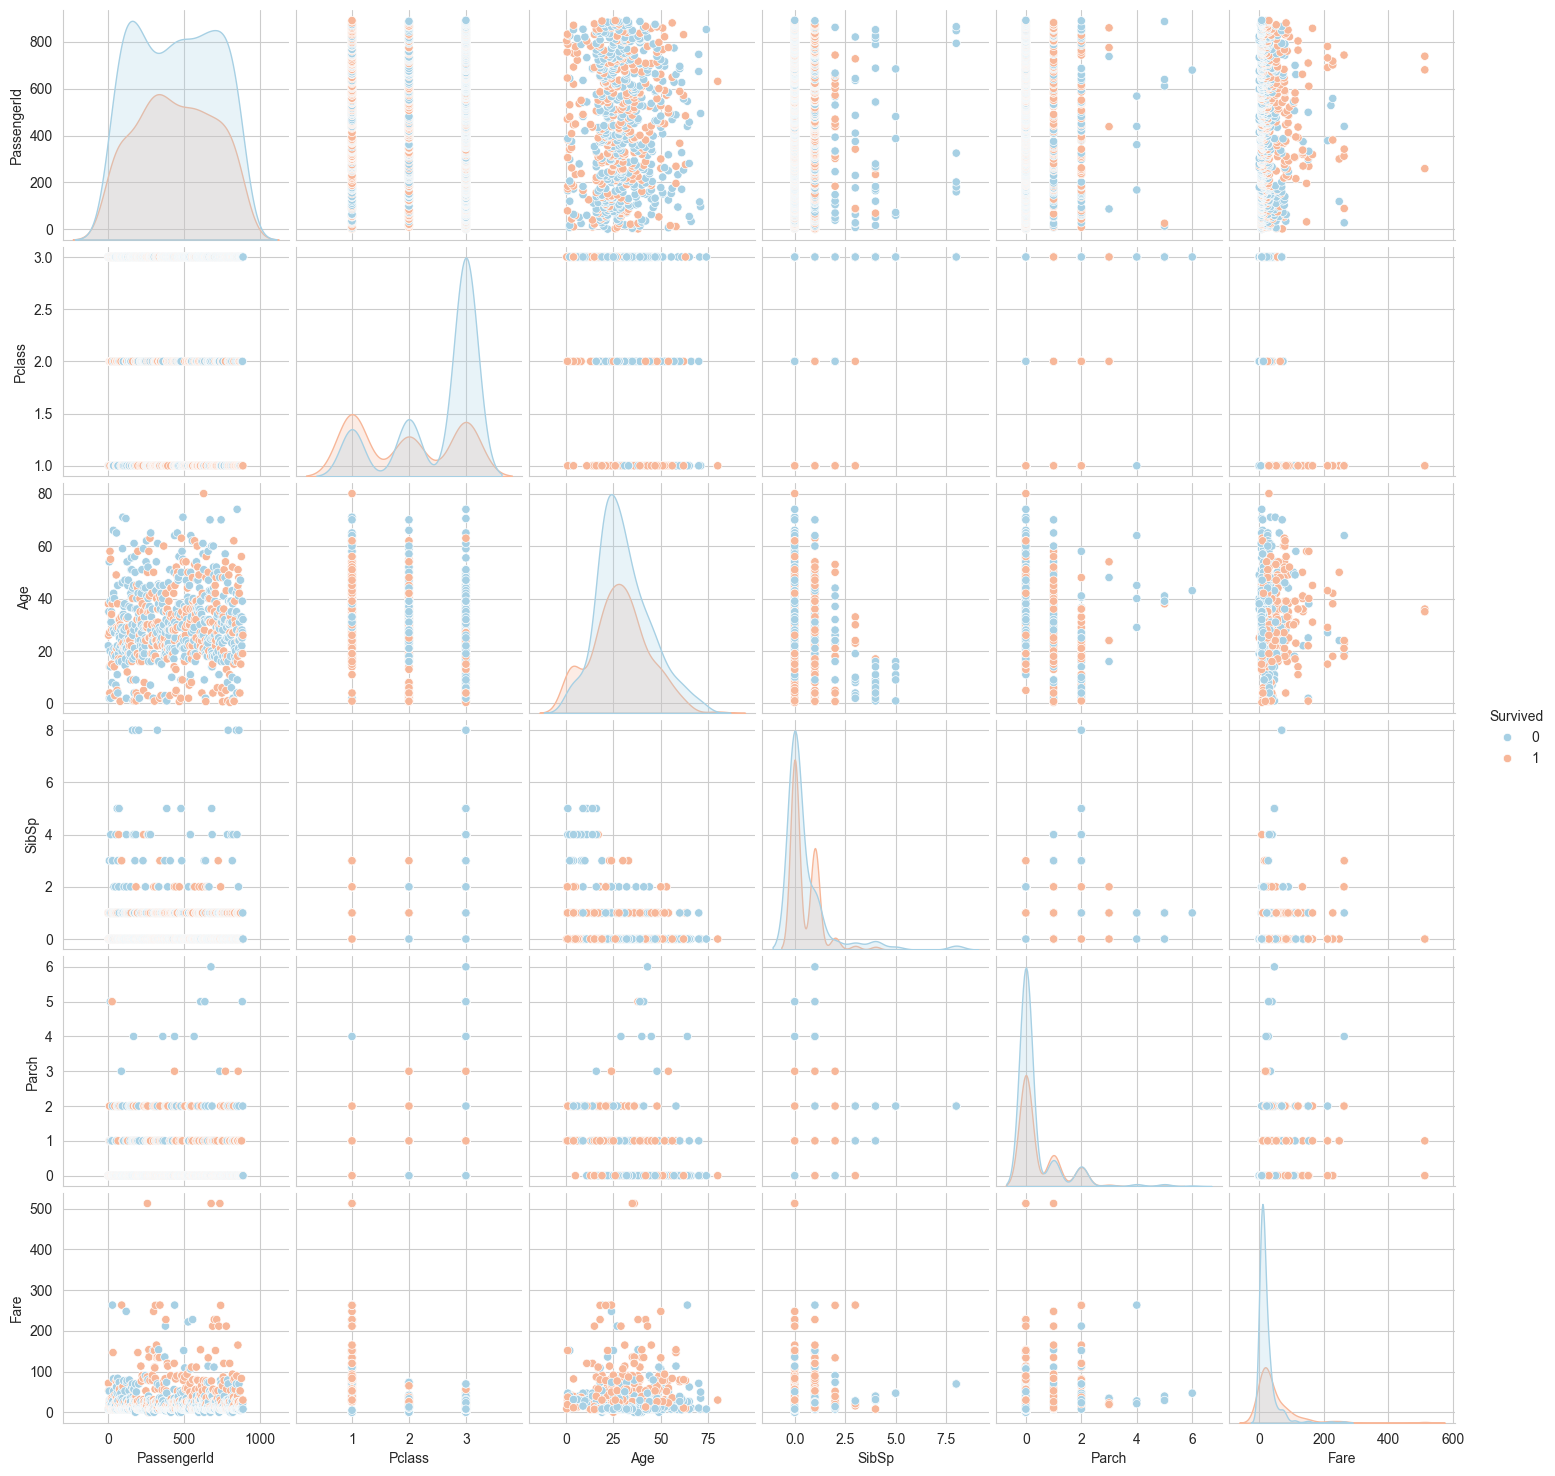

In [27]:
sns.pairplot(data, hue='Survived', palette='RdBu_r')

In [28]:
#Insight: Passengers who survived tend to be younger, have lower fares, and are more likely to be female.

## 🧹 Data Cleaning
Handle missing values and remove unnecessary columns.

In [29]:
def impute_age(cols):
    Age=cols[0]
    Pclass=cols[1]
    
    if pd.isnull(Age):
        if Pclass==1:
            return 37
        elif Pclass==2:
            return 29
        else:
            return 24
    else:
        return Age

In [30]:
data["Age"]=data[["Age","Pclass"]].apply(impute_age, axis=1)

C:\Users\G POORNIMADEVI\AppData\Local\Temp\ipykernel_14420\1953336446.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Age=cols[0]
C:\Users\G POORNIMADEVI\AppData\Local\Temp\ipykernel_14420\1953336446.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Pclass=cols[1]


In [31]:
# Since there are more than 700 missing values in the 'Cabin' column, we will drop it from the dataset. 

data.drop('Cabin', axis=1, inplace=True)

In [32]:
data.dropna(inplace=True)


## 🧠 Feature Engineering
We create new features to improve model performance:
- FamilySize: Total family members onboard



In [33]:
data["Sex"]=data["Sex"].map({'male':0, 'female':1})

In [34]:
data["FamilySize"]=data["SibSp"]+data["Parch"]+1

In [35]:
data.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C,2


In [36]:
data["Age Group"]=pd.cut(data["Age"], bins=[0,18,55,100], labels=['Child', 'Adult','Senior'])

In [37]:
data.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,Age Group
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,S,2,Adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C,2,Adult


In [38]:
data.drop(['PassengerId','Name','Ticket'], axis=1, inplace=True)

In [39]:
data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,Age Group
0,0,3,0,22.0,1,0,7.2500,S,2,Adult
1,1,1,1,38.0,1,0,71.2833,C,2,Adult
2,1,3,1,26.0,0,0,7.9250,S,1,Adult
3,1,1,1,35.0,1,0,53.1000,S,2,Adult
4,0,3,0,35.0,0,0,8.0500,S,1,Adult


## 🔄 Data Encoding
Convert categorical variables into numerical format.

In [40]:
# one-hot encoding
data = pd.get_dummies(data, columns=['Age Group'], drop_first=True)
data = pd.get_dummies(data, columns=['Embarked'], drop_first=True)

In [41]:
data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,Age Group_Adult,Age Group_Senior,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,2,True,False,False,True
1,1,1,1,38.0,1,0,71.2833,2,True,False,False,False
2,1,3,1,26.0,0,0,7.9250,1,True,False,False,True
3,1,1,1,35.0,1,0,53.1000,2,True,False,False,True
4,0,3,0,35.0,0,0,8.0500,1,True,False,False,True


## 💾 Save Cleaned Dataset
Save cleaned data for model building.

In [44]:
data.to_csv('../data/cleaned.csv', index=False)

## 🧾 Conclusion

- Performed data exploration and visualization
- Identified and handled missing values
- Removed unnecessary columns
- Prepared clean dataset for machine learning

The cleaned data is now ready for model building.